<a href="https://colab.research.google.com/github/arsalsaeed27/PyTorch/blob/main/01_pytorch_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### PyTorch WorkFlow

In [1]:
what_were_covering = {1: "data (prepare and load)" ,
                      2: "build model",
                      4: "fitting the model to data (training)",
                      5: "savinng and loading the model",
                      6: "getting it all together"}

In [2]:
import torch
from torch import nn # nn = neural network
import matplotlib.pyplot as plt

torch.__version__

'2.11.0+cpu'

## 1. Data (Preparing and loading)

Data can be anything... in ML

1. Get data in numerical representaion
2. Build a model to learn patterns in that

Let's create some *known* data using Linear Regression formula.

We'll use a LR formula to make a straight line with *known* **parameters**

**(Y = a+bX)**

A *parameter* is something that a model learns

In [3]:
# Create *known* parameters
weight = 0.7 # b
bias = 0.3 # a

# Create
start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight*X + bias # y = mx+ c

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

### Splitting data into training and test sets

Let's create a training and test set with our data

In [4]:
len(X), len(y)

(50, 50)

In [5]:
# create a train/test split
train_split = int(0.8* len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test , y_test = X[train_split:], y[train_split:]

In [6]:
len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

### Viusalizing Data

In [7]:
def plot_predictions(train_data = X_train,
                     train_labels = y_train,
                     test_data = X_test,
                     test_labels = y_test,
                     predictions = None):
  """
Plots training data, test data, and compares predictions
  """
  plt.figure(figsize=(10,7))
  # Blue Scatter
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training Data")
  # Green Scatter
  plt.scatter(test_data, test_labels, c="g", s=4,label = "Testing Data")
  # Predicitions?
  if predictions is not None:
    plt.scatter(test_data,predictions,c="r", s=4,label = "Predictions")

  plt.legend()

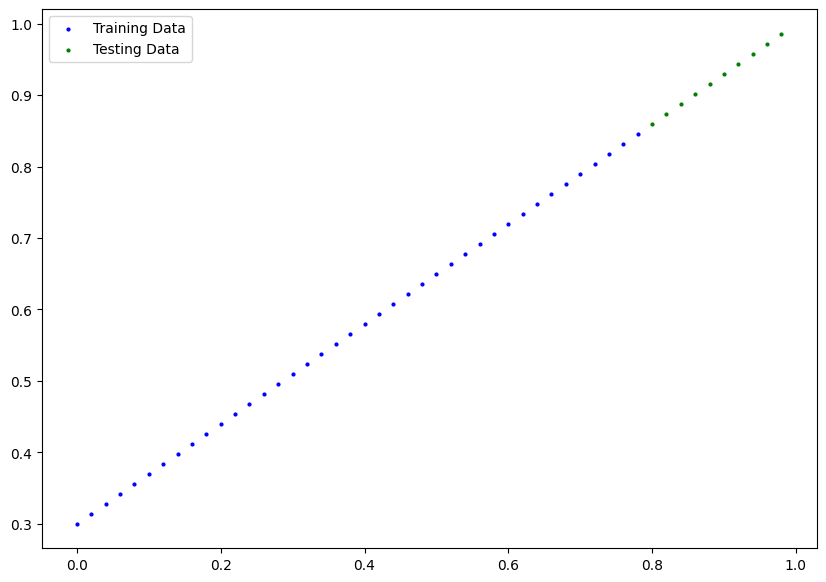

In [8]:
plot_predictions()

## 2. Build Model

What our model does:
* Start with random values (W, B)
* Look at training data and adjust the random values to better represent (or get closer to) the ideal values of W an B

Through 2 main Algos:
1. Gradient Descent
2. Backpropagation

In [9]:
# Create linear regression model class
class LinearRegressionModel(nn.Module): #<- Building Blocks for NN
  def __init__(self):
    super().__init__()
    # Init model parameters
    self.weights = nn.Parameter(torch.randn(1,
                                            requires_grad=True, # by default
                                            dtype=torch.float))
    self.bias = nn.Parameter(torch.randn(1,
                                          requires_grad=True,
                                          dtype=torch.float))
    # Forward method to define computatuon in the model
  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.weights * x + self.bias # LR formula

### PyTorch model building essentials

* torch.nn - contans all of the building blocks for computational graphs
* torch.nn.Parameter - what parameters should our model try and learn
* torch.nn.Module - base class for all neural network modules
* torch.optim - this where the optimizers in PyTorch live, they help GD
* def forward() - all nn modules require you to override this function

### Checking the contents of out PyTorch model

Now we've created a model, let's see whats inside
So we can check out model parameters or whats inside our model using `.parameters()`

In [10]:
import torch
# random manual seed
torch.manual_seed(42)
model_0 = LinearRegressionModel()
# check out the parameters
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [11]:
# List named parameters
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

### Making predictions using `torch.inference_mode()`

To test our models predictive power, let's see how well it predicts `y_test` based on `X_test`

When we pass data through our model, it is going to run through the `forward()` method

In [12]:
y_test # actual

tensor([[0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160],
        [0.9300],
        [0.9440],
        [0.9580],
        [0.9720],
        [0.9860]])

In [13]:
# making prediction with model
with torch.inference_mode():
  y_preds = model_0(X_test)
y_preds # prediction

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

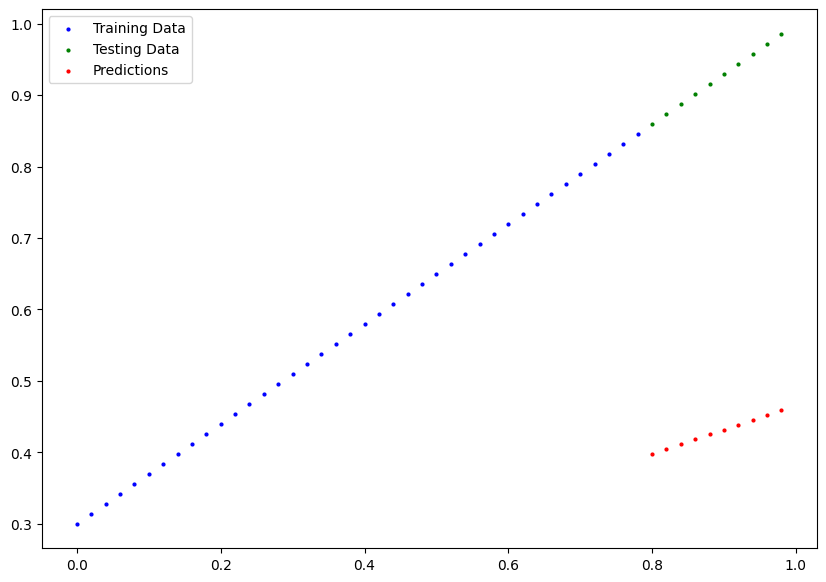

In [14]:
plot_predictions(predictions= y_preds)
# tooooooo far, we have to improve

## 3. Train Model
The whole idea of training is for a model to move from some *unknown* parameters to some *known* parameters

Or in other words, from a poor representation of data to a better representation of the data

One way to measure how poor / wrong your model is to use a `loss function` (cost function / criterarion )

* **Loss Function:** A function to measure how wrong your model's predictions are to the ideal outputs. *LOWER IS BETTER :)*

* **Optimizer:** Takes into account the loss of a model and adjusts the model's parameters, e.g weight and bias, to improve the loss function

For PyTorch we need:
* A training loop
* A testing loop